# S19 · How a backtest lies, and how to stop it

In notebook 01 the honest answer was that the 20/50 rule on HDFC Bank did not beat buy
and hold. Now we break the same backtest on purpose, one trap at a time, and measure
how much each lie flatters the result:

1. **look-ahead bias**: peeking at the future;
2. **trying too many rules**: keeping the lucky winner;
3. **ignoring costs**: pretending trades are free.

A fourth trap, survivorship bias, is about the data itself; it is explained in words at
the end of Trap 1. Recognising these traps is the most valuable thing in this session.

**New here? Read this once.**

- New to Python? You can still do this whole notebook. Press the play button on each
  cell, top to bottom, and read the plain-English note above each one.
- New to "is this real or just luck"? `primers/hypothesis_testing_and_pvalues.md` is a
  ten-minute, picture-first read.
- Already confident with code or with trading? Look for the cells marked
  **Stretch (optional)** near the end.
- Stuck on a word? It is in `primers/glossary.md`.

## Setup

On **Google Colab**, run the next cell once. On your **own machine** you already
installed everything with `uv`, so it does nothing there.

In [1]:
# This notebook uses numpy, pandas and matplotlib, which Colab already ships.
print("Setup complete - nothing to install.")

Setup complete - nothing to install.


## Step 1 — load the prices

Daily closing prices of HDFC Bank and ICICI Bank on the NSE, January 2019 to December
2025. They were downloaded once with
`yf.download(["HDFCBANK.NS", "ICICIBANK.NS"], start="2019-01-01", end="2026-01-01", auto_adjust=True)`
and saved, so everyone gets exactly the numbers on the slides, with or without internet.

In [2]:
from pathlib import Path
import numpy as np                 # fast maths on lists of numbers
import pandas as pd                # tables of data with dates
import matplotlib.pyplot as plt    # charts

# Where the saved prices live: next to this notebook, or on the course website.
local_copy = Path("../data/hdfc_icici_2019_2025.csv")
website_copy = ("https://girishmkulkarni.github.io/applied-maths-in-industry-site/"
                "sessions/S19/data/hdfc_icici_2019_2025.csv")

if local_copy.exists():
    prices = pd.read_csv(local_copy, index_col=0, parse_dates=True)
else:
    prices = pd.read_csv(website_copy, index_col=0, parse_dates=True)

print("days of prices:", len(prices))
print("from", prices.index[0].date(), "to", prices.index[-1].date())
prices.tail()

days of prices: 1730
from 2019-01-01 to 2025-12-31


,HDFCBANK,ICICIBANK
Date,,
2025-12-24,980.9752,1348.4321
2025-12-26,975.9582,1339.1106
2025-12-29,975.5647,1332.0701
2025-12-30,974.7778,1331.2766
2025-12-31,975.0729,1331.6733


## Step 2 — rebuild the honest backtest from notebook 01

In [3]:
price = prices["HDFCBANK"]
stock_return = price.pct_change()

fast = price.rolling(20).mean()
slow = price.rolling(50).mean()
position = (fast > slow).astype(int)                # 1 = own, 0 = cash

strategy_return = position.shift(1) * stock_return  # the honest version
print("honest: Rs 1 became", round((1 + strategy_return).prod(), 2))
print("hold  : Rs 1 became", round((1 + stock_return).prod(), 2))

honest: Rs 1 became 1.05
hold  : Rs 1 became 1.97


## Trap 1 — look-ahead bias

We only know today's averages **after** today's close. Trading at that same close is
impossible. But delete one `shift(1)` and the code will happily do it: on the day a big
rise pushes the fast average above the slow one, the cheat is already holding the stock
and pockets that rise.

In [4]:
honest = position.shift(1) * stock_return   # decide yesterday, earn today
cheat  = position * stock_return            # decide AND earn today: peeking

print("honest:", round((1 + honest).prod(), 2))
print("cheat :", round((1 + cheat).prod(), 2))

honest: 1.05
cheat : 1.23


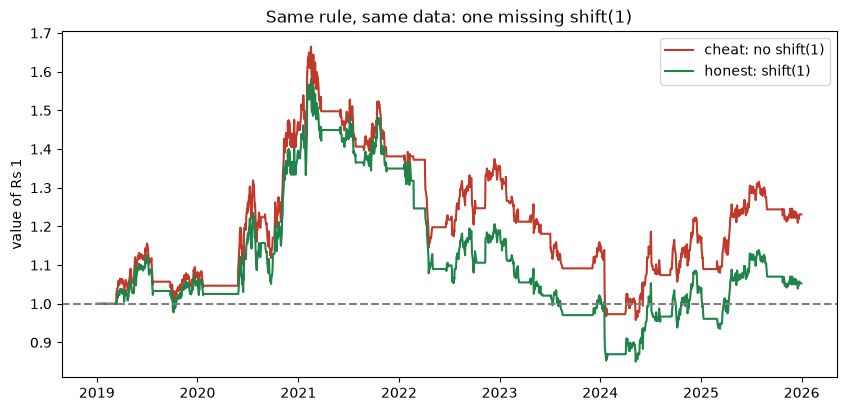

In [5]:
plt.figure(figsize=(10, 4.5))
plt.plot((1 + cheat.fillna(0)).cumprod(), color="#C0392B", label="cheat: no shift(1)")
plt.plot((1 + honest.fillna(0)).cumprod(), color="#1E8449", label="honest: shift(1)")
plt.axhline(1, color="grey", linestyle="--")
plt.ylabel("value of Rs 1")
plt.title("Same rule, same data: one missing shift(1)")
plt.legend()
plt.show()

Nothing about the strategy changed; only the honesty did. The fix is a habit: shift
every signal before you believe a number.

**A cousin: survivorship bias.** If you backtest "buy Nifty 50 stocks" using *today's*
list of members, you only test companies that survived. Yes Bank was in the Nifty 50 until
March 2020, after falling more than 80% from its 2018 high; it is not on today's list, so
your backtest never has to live through its collapse. The fix is point-in-time data: the
index as it really was on each date, dead names included.

## Trap 2 — try enough rules and one will look brilliant

First with pure noise. Each "rule" below is two years of random daily returns with an
average of **zero**: no edge at all. Yet some of them will look wonderful.

In [6]:
np.random.seed(1)
results = []
for i in range(200):
    r = np.random.normal(0, 0.01, 500)    # a rule with NO edge: pure noise
    results.append((1 + r).prod())

print("average rule:", round(np.mean(results), 2))
print("best rule   :", round(max(results), 2))
print("rules that made 20% or more:", sum(x > 1.2 for x in results))

average rule: 1.03
best rule   : 1.75
rules that made 20% or more: 44


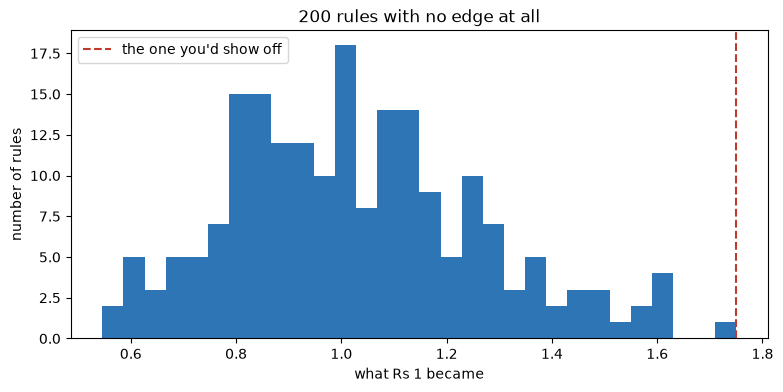

In [7]:
plt.figure(figsize=(9, 4))
plt.hist(results, bins=30, color="#2E75B6")
plt.axvline(max(results), color="#C0392B", linestyle="--", label="the one you'd show off")
plt.xlabel("what Rs 1 became")
plt.ylabel("number of rules")
plt.title("200 rules with no edge at all")
plt.legend()
plt.show()

Now the same trap with real knobs. We try 19 pairs of window lengths on **2019–2022**
and keep the best. Then we run that winner, unchanged, on **2023–2025**, years it never
saw. This is the train/test split from S07, applied to time.

In [8]:
def rule_returns(f, s):
    pos = (price.rolling(f).mean() > price.rolling(s).mean()).astype(int)
    return pos.shift(1) * stock_return

tried = {}
for f in [5, 10, 20, 30, 50]:
    for s in [50, 100, 150, 200]:
        if f < s:
            r = rule_returns(f, s)
            tried[(f, s)] = ((1 + r.loc[:"2022"]).prod(),     # tuning years
                             (1 + r.loc["2023":]).prod())     # fresh years

best = max(tried, key=lambda k: tried[k][0])
print("settings tried:", len(tried))
print("best on 2019-22:", best, "-> Rs 1 became", round(tried[best][0], 2))
print("same rule on 2023-25     -> Rs 1 became", round(tried[best][1], 2))
print("just holding on 2023-25  -> Rs 1 became",
      round(price.iloc[-1] / price.loc[:"2022"].iloc[-1], 2))

settings tried: 19
best on 2019-22: (30, 100) -> Rs 1 became 1.4
same rule on 2023-25     -> Rs 1 became 0.93
just holding on 2023-25  -> Rs 1 became 1.27


The tuned winner lost money on the fresh years while simply holding HDFC Bank made
money. The tuning found the quirks of 2019–2022, not a lasting pattern. **Tune on one
stretch of history. Judge on another, once**, and do not go back and re-tune after you
have looked at the test.

## Trap 3 — every trade costs money

Brokerage, STT (securities transaction tax), stamp duty, exchange fees, GST on the fees,
and **slippage**, the gap between the price you wanted and the price you got. We charge
a gentle 0.1% on every buy and every sell.

A trade happens whenever the position changes, so `position.diff().abs()` is 1 on every
trading day. We pay the cost on the day the order fills, one day later: `.shift(1)`.

In [9]:
trades = position.diff().abs()                # 1 on every buy or sell day
net_return = strategy_return - 0.001 * trades.shift(1)   # pay 0.1% per trade

print("trades      :", int(trades.sum()))
print("before costs:", round((1 + strategy_return).prod(), 3))
print("after costs :", round((1 + net_return).prod(), 3))

trades      : 44
before costs: 1.052
after costs : 1.007


Our slow rule trades only a few times a year, so costs take only a little. A fast rule
trades far more. Compare a 5/20 rule:

In [10]:
fast_pos = (price.rolling(5).mean() > price.rolling(20).mean()).astype(int)
fast_trades = fast_pos.diff().abs()
fast_gross = fast_pos.shift(1) * stock_return
fast_net = fast_gross - 0.001 * fast_trades.shift(1)

print("5/20 rule trades:", int(fast_trades.sum()))
print("before costs    :", round((1 + fast_gross).prod(), 3))
print("after costs     :", round((1 + fast_net).prod(), 3))

5/20 rule trades: 120
before costs    : 1.078
after costs     : 0.957


If an edge survives only at zero cost, it does not exist.

### Stretch (optional) — the hypothesis-testing view

Skip this if you just want the practical lesson. Think of each rule as a claim, with the
null hypothesis "this rule has no edge". A gorgeous backtest is like a small p-value.
But if you run 200 tests at the 5% level, about 10 pass by luck alone, and about half of
those (around 5) pass on the "made money" side. The simulation below runs a simple t-test
on each noise rule; with this seed only a couple pass, but with many rules some always do.

In [11]:
from scipy.stats import ttest_1samp

np.random.seed(2)
passed = 0
for i in range(200):
    r = np.random.normal(0, 0.01, 500)          # no edge
    if ttest_1samp(r, 0).pvalue < 0.05 and r.mean() > 0:
        passed += 1
print("noise rules that 'significantly' made money:", passed, "of 200")

noise rules that 'significantly' made money: 2 of 200


## Your turn

Charge a realistic **0.3%** per trade instead of 0.1% for both the 20/50 and the 5/20
rules. Which one survives? What does that tell you about fast rules?

In [12]:
# Your code here: redo Trap 3 with 0.003 instead of 0.001.

## What you just did

You made the same backtest lie three ways and measured each lie: a missing `shift(1)`,
a tuned-until-it-shone setting, and free trades. Every one flattered the rule. The honest
checklist: shift your signals, fix settings on one period and test once on the next,
charge realistic costs, use point-in-time data, and always compare with buy and hold.
**A trading strategy is easy. An honest backtest is hard.**